In [1]:
#Import Libraries
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
#Get Total Frames
video_path = "vdo1.mp4"
cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total Frames:", total_frames)

cap.release()

Total Frames: 633


In [4]:
#Randomly Select 30 Unique Frame Numbers
random_frames = random.sample(range(total_frames), 30)
random_frames.sort()

print(random_frames)

[7, 14, 27, 73, 97, 129, 196, 216, 232, 285, 301, 313, 411, 422, 440, 454, 491, 508, 509, 515, 518, 526, 541, 542, 552, 554, 564, 580, 600, 623]


In [5]:
#Extract Those 30 Frames
output_folder = "random_30_frames"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

cap = cv2.VideoCapture(video_path)

current_frame = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if current_frame in random_frames:
        resized = cv2.resize(frame, (640, 480))
        cv2.imwrite(f"{output_folder}/frame_{saved_count}.jpg", resized)
        saved_count += 1

    current_frame += 1

cap.release()

print("Random 30 Frames Saved:", saved_count)

Random 30 Frames Saved: 30


In [6]:
#for i in range(30):
   # path = f"random_30_frames/frame_{i}.jpg"
    #img = cv2.imread(path)
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [6]:
path = "random_30_frames/frame_0.jpg"

img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [7]:
#Method 1 – Contrast Stretching
min_val = np.min(gray)
max_val = np.max(gray)

stretched = ((gray - min_val) / (max_val - min_val)) * 255
stretched = stretched.astype(np.uint8)

In [8]:
#Method 2 – CLAHE
clahe = cv2.createCLAHE(2.0, (8,8))
enhanced = clahe.apply(gray)

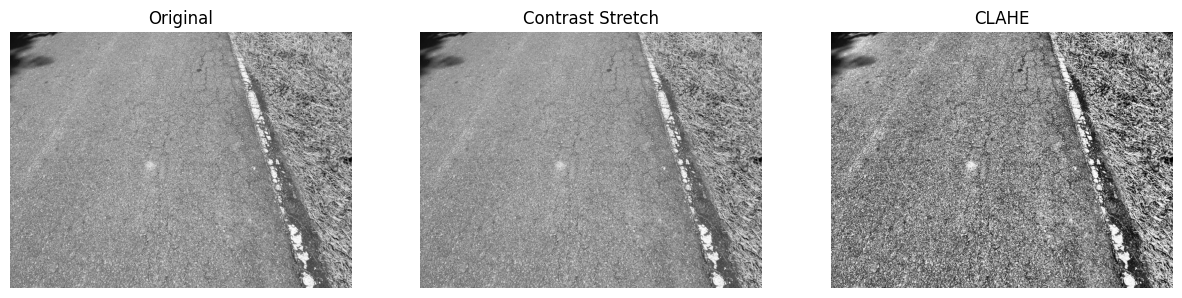

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(stretched, cmap='gray')
plt.title("Contrast Stretch")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE")
plt.axis("off")

plt.show()

/tmp/ipython-input-17995/116131706.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])
/tmp/ipython-input-17995/116131706.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(stretched.ravel(), 256, [0,256])
/tmp/ipython-input-17995/116131706.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(enhanced.ravel(), 256, [0,256])


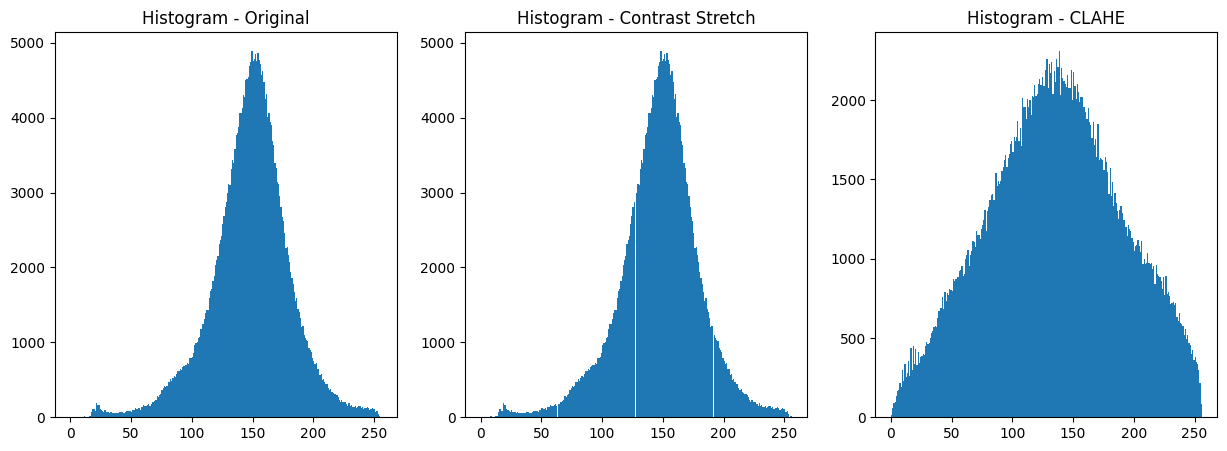

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(gray.ravel(), 256, [0,256])
plt.title("Histogram - Original")

plt.subplot(1,3,2)
plt.hist(stretched.ravel(), 256, [0,256])
plt.title("Histogram - Contrast Stretch")

plt.subplot(1,3,3)
plt.hist(enhanced.ravel(), 256, [0,256])
plt.title("Histogram - CLAHE")

plt.show()

In [11]:
def calculate_entropy(image):
    histogram, _ = np.histogram(image.flatten(), bins=256, range=(0,256))
    histogram = histogram / histogram.sum()
    histogram = histogram[histogram > 0]
    return -np.sum(histogram * np.log2(histogram))

entropy_original = calculate_entropy(gray)
entropy_stretch = calculate_entropy(stretched)
entropy_clahe = calculate_entropy(enhanced)

print("Entropy Comparison")
print("Original:", entropy_original)
print("Contrast Stretch:", entropy_stretch)
print("CLAHE:", entropy_clahe)

Entropy Comparison
Original: 7.012614797912914
Contrast Stretch: 7.012614797912914
CLAHE: 7.782012680808986
